# Predictive Modelling for Customer Lifetime Value

This notebook develops predictive models for Customer Lifetime Value analysis. The first objective is to predict whether a customer will make at least one purchase during the future observation period.

Because `RepeatPurchase` is a binary outcome, where 1 represents a repeat customer and 0 represents a non-repeat customer, logistic regression is used.

The second objective, completed after the classification model, is to predict the future revenue generated by returning customers. The two predictions will ultimately be combined as:

$$
\widehat{CLV}_i
=
P(\text{Repeat Purchase}_i=1)
\times
E(\text{Future Revenue}_i\mid\text{Repeat Purchase}_i=1)
$$

All predictor variables are calculated using transactions from the historical period. Variables calculated from the future period are excluded from the inputs to prevent data leakage.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customer_data = pd.read_csv("/content/drive/MyDrive/Data/data/processed/customer_clv_model.csv")

print("Dataset shape:", customer_data.shape)
customer_data.head()

Dataset shape: (4266, 30)


,CustomerID,LastPurchase,Frequency,MonetaryValue,TotalQuantity,ProductDiversity,RecencyDays,FuturePurchaseCount,FutureRevenue,RepeatPurchase,...,ActivePurchaseDays,CustomerTenureDays,ReturnInvoiceCount,ReturnLineCount,HistoricalReturnValue,ReturnInvoiceRate,AverageDaysBetweenOrders,StdDaysBetweenOrders,PrimaryCountry,IsUK
0,12346,2010-06-28 13:53:00,11,372.86,70,26,155,1.0,77183.60,1,...,7,351,4.0,12.0,424.60,0.266667,19.622153,36.622360,United Kingdom,1
1,12347,2010-10-31 14:20:00,1,611.53,509,40,30,7.0,4310.00,1,...,1,30,0.0,0.0,0.00,0.000000,0.000000,0.000000,Iceland,0
2,12348,2010-09-27 14:59:00,1,222.16,373,20,64,4.0,1797.24,1,...,1,64,0.0,0.0,0.00,0.000000,0.000000,0.000000,Finland,0
3,12349,2010-10-28 08:23:00,3,2671.14,993,90,33,1.0,1757.55,1,...,3,215,1.0,5.0,24.15,0.250000,90.896875,101.876901,Italy,0
4,12351,2010-11-29 15:23:00,1,300.93,261,21,1,0.0,0.00,0,...,1,1,0.0,0.0,0.00,0.000000,0.000000,0.000000,Unspecified,0


In [3]:
customer_data.columns.tolist()

['CustomerID',
 'LastPurchase',
 'Frequency',
 'MonetaryValue',
 'TotalQuantity',
 'ProductDiversity',
 'RecencyDays',
 'FuturePurchaseCount',
 'FutureRevenue',
 'RepeatPurchase',
 'AverageOrderValue',
 'MaximumOrderValue',
 'LogFrequency',
 'LogMonetaryValue',
 'LogAverageOrderValue',
 'LogTotalQuantity',
 'LogProductDiversity',
 'LogFutureRevenue',
 'FirstPurchase',
 'ActiveMonths',
 'ActivePurchaseDays',
 'CustomerTenureDays',
 'ReturnInvoiceCount',
 'ReturnLineCount',
 'HistoricalReturnValue',
 'ReturnInvoiceRate',
 'AverageDaysBetweenOrders',
 'StdDaysBetweenOrders',
 'PrimaryCountry',
 'IsUK']

In [4]:
model_data = customer_data.copy()

model_data["LogFrequency"] = np.log1p(
    model_data["Frequency"]
)

model_data["LogMonetaryValue"] = np.log1p(
    model_data["MonetaryValue"].clip(lower=0)
)

model_data["LogAverageOrderValue"] = np.log1p(
    model_data["AverageOrderValue"].clip(lower=0)
)

model_data["LogTotalQuantity"] = np.log1p(
    model_data["TotalQuantity"].clip(lower=0)
)

model_data["LogProductDiversity"] = np.log1p(
    model_data["ProductDiversity"].clip(lower=0)
)

In [5]:
features = [
    "RecencyDays",
    "LogFrequency",
    "LogMonetaryValue",
    "LogAverageOrderValue",
    "LogTotalQuantity",
    "LogProductDiversity",
    "IsUK"
]

target = "RepeatPurchase"

X = model_data[features].copy()
y = model_data[target].astype(int)

print("Predictor shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Predictor shape: (4266, 7)

Target distribution:
RepeatPurchase
1    2726
0    1540
Name: count, dtype: int64

Target percentages:
RepeatPurchase
1    63.9
0    36.1
Name: proportion, dtype: float64


In [6]:
print("Missing values:")
print(X.isnull().sum())

print("\nInfinite values:")
print(np.isinf(X.select_dtypes(include=np.number)).sum())

Missing values:
RecencyDays             0
LogFrequency            0
LogMonetaryValue        0
LogAverageOrderValue    0
LogTotalQuantity        0
LogProductDiversity     0
IsUK                    0
dtype: int64

Infinite values:
RecencyDays             0
LogFrequency            0
LogMonetaryValue        0
LogAverageOrderValue    0
LogTotalQuantity        0
LogProductDiversity     0
IsUK                    0
dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training customers:", len(X_train))
print("Testing customers:", len(X_test))

print("\nTraining repeat rate:")
print(y_train.mean().round(4))

print("\nTesting repeat rate:")
print(y_test.mean().round(4))

Training customers: 3412
Testing customers: 854

Training repeat rate:
0.6389

Testing repeat rate:
0.6393


### Logistic Regression

Logistic regression estimates the probability that a customer belongs to the positive class:

$$
p_i=P(Y_i=1\mid X_i)
$$

In this study, \(Y_i=1\) means that customer \(i\) made at least one purchase during the future period.

A linear combination of predictor variables can produce values outside the probability range of zero to one. Logistic regression therefore models the log-odds of the event:

$$
\log\left(\frac{p_i}{1-p_i}\right)
=
\beta_0+\beta_1X_{i1}+\cdots+\beta_kX_{ik}
$$

The probability is obtained through the logistic function:

$$
p_i=
\frac{1}
{1+\exp[-(\beta_0+\beta_1X_{i1}+\cdots+\beta_kX_{ik})]}
$$

The model produces probabilities between zero and one. Using a default classification threshold of 0.50:

$$
\hat{Y}_i=
\begin{cases}
1, & \hat{p}_i\geq0.50\\
0, & \hat{p}_i<0.50
\end{cases}
$$

A positive coefficient indicates that increasing the corresponding predictor increases the log-odds of repeat purchasing. A negative coefficient indicates that it decreases the log-odds.

The exponential of a coefficient produces an odds ratio:

$$
OR_j=e^{\beta_j}
$$

An odds ratio greater than one represents increasing odds, while an odds ratio below one represents decreasing odds.


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [9]:
y_probability = logistic_model.predict_proba(X_test)[:, 1]
y_prediction = logistic_model.predict(X_test)

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_prediction
).ravel()

specificity = tn / (tn + fp)

metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, y_prediction),
    "Precision": precision_score(y_test, y_prediction),
    "Recall": recall_score(y_test, y_prediction),
    "Specificity": specificity,
    "F1-score": f1_score(y_test, y_prediction),
    "ROC-AUC": roc_auc_score(y_test, y_probability),
    "PR-AUC": average_precision_score(
        y_test,
        y_probability
    )
})

print(metrics.round(4))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_prediction,
    target_names=["Did not return", "Returned"]
))

Accuracy       0.7365
Precision      0.7635
Recall         0.8516
Specificity    0.5325
F1-score       0.8052
ROC-AUC        0.7897
PR-AUC         0.8677
dtype: float64

Classification report:
                precision    recall  f1-score   support

Did not return       0.67      0.53      0.59       308
      Returned       0.76      0.85      0.81       546

      accuracy                           0.74       854
     macro avg       0.72      0.69      0.70       854
  weighted avg       0.73      0.74      0.73       854



In [11]:
baseline_accuracy = y_test.value_counts(
    normalize=True
).max()

print(f"Majority-class baseline: {baseline_accuracy:.4f}")
print(
    f"Logistic regression accuracy: "
    f"{accuracy_score(y_test, y_prediction):.4f}"
)

Majority-class baseline: 0.6393
Logistic regression accuracy: 0.7365


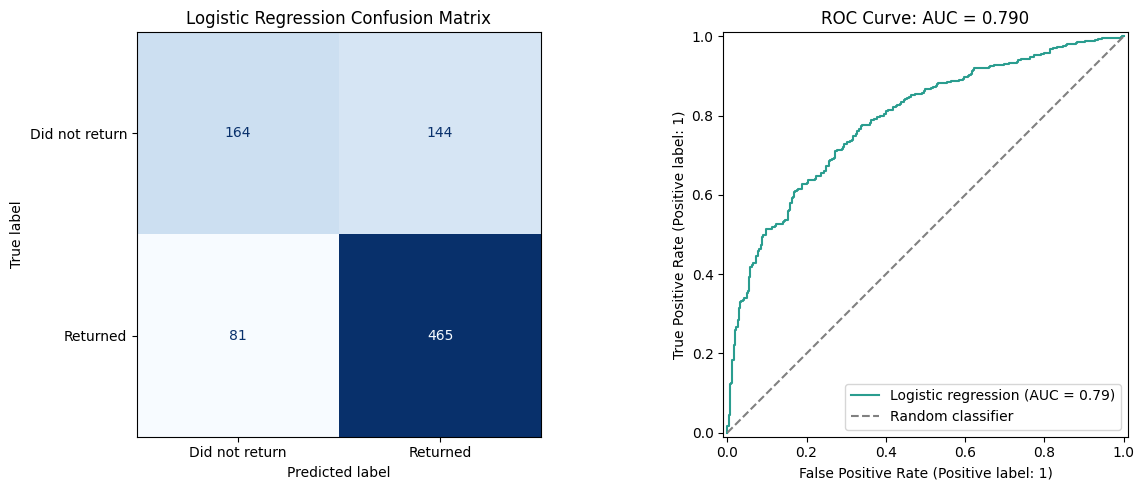

In [12]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_prediction,
    display_labels=["Did not return", "Returned"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0]
)

axes[0].set_title("Logistic Regression Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    name="Logistic regression",
    color="#2A9D8F",
    ax=axes[1]
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

axes[1].set_title(
    f"ROC Curve: AUC = "
    f"{roc_auc_score(y_test, y_probability):.3f}"
)

axes[1].legend()

plt.tight_layout()
plt.savefig(
    "logistic_regression_evaluation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [13]:
coefficients = logistic_model.named_steps[
    "model"
].coef_[0]

coefficient_table = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients,
    "OddsRatio": np.exp(coefficients)
})

coefficient_table["Direction"] = np.where(
    coefficient_table["Coefficient"] > 0,
    "Increases repeat-purchase odds",
    "Decreases repeat-purchase odds"
)

coefficient_table = coefficient_table.sort_values(
    "Coefficient",
    ascending=False
)

coefficient_table.round(4)

,Feature,Coefficient,OddsRatio,Direction
1,LogFrequency,0.5235,1.6879,Increases repeat-purchase odds
2,LogMonetaryValue,0.3403,1.4054,Increases repeat-purchase odds
4,LogTotalQuantity,0.2576,1.2938,Increases repeat-purchase odds
5,LogProductDiversity,0.0861,1.0899,Increases repeat-purchase odds
6,IsUK,-0.0356,0.9650,Decreases repeat-purchase odds
3,LogAverageOrderValue,-0.1115,0.8945,Decreases repeat-purchase odds
0,RecencyDays,-0.4192,0.6576,Decreases repeat-purchase odds


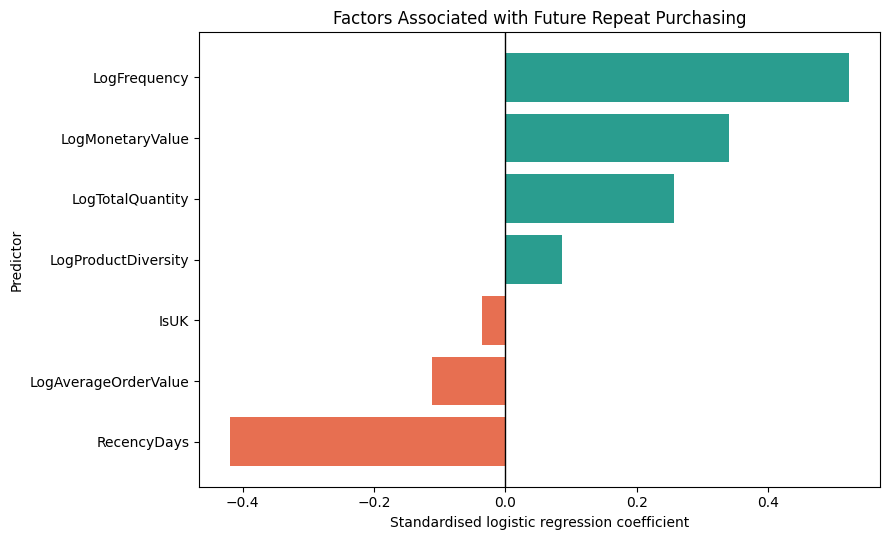

In [14]:
plot_data = coefficient_table.sort_values(
    "Coefficient"
)

colors = np.where(
    plot_data["Coefficient"] > 0,
    "#2A9D8F",
    "#E76F51"
)

plt.figure(figsize=(9, 5.5))

plt.barh(
    plot_data["Feature"],
    plot_data["Coefficient"],
    color=colors
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.xlabel("Standardised logistic regression coefficient")
plt.ylabel("Predictor")
plt.title("Factors Associated with Future Repeat Purchasing")

plt.tight_layout()
plt.savefig(
    "logistic_regression_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Logistic Regression Results and Interpretation

The logistic regression model was evaluated using a separate test set containing 854 customers. The model achieved an accuracy of 73.65%, compared with a majority-class baseline accuracy of 63.93%. Therefore, the model improved accuracy by approximately 9.72 percentage points over predicting that every customer would return.

The confusion matrix produced the following results:

* 164 non-returning customers were correctly classified as non-returning.
* 144 non-returning customers were incorrectly classified as returning.
* 81 returning customers were incorrectly classified as non-returning.
* 465 returning customers were correctly classified as returning.

The model achieved a recall of 85.16% for returning customers. This means that approximately 85 out of every 100 customers who actually returned were successfully identified by the model.

Precision was 76.35%, meaning that approximately 76 out of every 100 customers predicted to return actually made a repeat purchase.

The F1-score was 80.52%. The F1-score is the harmonic mean of precision and recall:

$$
F_1
=
2\left(
\frac{\text{Precision}\times\text{Recall}}
{\text{Precision}+\text{Recall}}
\right)
$$

This result indicates a good balance between correctly identifying returning customers and limiting false positive predictions.

Specificity was 53.25%. Therefore, the model correctly identified approximately 53% of customers who did not return. Specificity was lower than recall because the model was more successful at identifying repeat customers than non-repeat customers.

The ROC-AUC was 0.7897. This means that when one returning customer and one non-returning customer are randomly selected, the model has approximately a 79% probability of assigning the higher repeat-purchase probability to the returning customer. An AUC of 0.50 represents random classification, while an AUC of 1.00 represents perfect discrimination.

The precision-recall AUC was 0.8677, which was substantially higher than the positive-class prevalence of approximately 0.639. This provides further evidence that the model successfully distinguishes customers likely to return.

Overall, the model demonstrates good discriminatory performance. Its high recall is valuable for customer-retention applications because it identifies most customers who will make a future purchase. However, its moderate specificity means that some customers predicted to return will not actually return.

### Coefficient Interpretation

The predictor variables were standardised before model estimation. Therefore, each coefficient represents the change associated with an increase of one standard deviation in the corresponding predictor while holding the other model variables constant.

Historical purchase frequency had the largest positive coefficient:

$$
\beta=0.5235,\qquad OR=e^{0.5235}=1.6879
$$

A one-standard-deviation increase in log purchase frequency was associated with approximately 68.79% higher odds of making a repeat purchase.

Historical monetary value also had a positive relationship:

$$
\beta=0.3403,\qquad OR=1.4054
$$

A one-standard-deviation increase in log monetary value was associated with approximately 40.54% higher repeat-purchase odds.

Log total quantity had an odds ratio of 1.2938. Therefore, a one-standard-deviation increase was associated with approximately 29.38% higher odds of repeat purchasing.

Product diversity had a smaller positive association, with an odds ratio of 1.0899, corresponding to approximately 8.99% higher odds.

Recency had an important negative coefficient:

$$
\beta=-0.4192,\qquad OR=0.6576
$$

Higher `RecencyDays` means that more time has passed since the customer’s last purchase. A one-standard-deviation increase in recency was therefore associated with a reduction of approximately:

$$
(1-0.6576)\times100=34.24\%
$$

in the odds of making a repeat purchase. Customers who purchased more recently were consequently more likely to return.

The UK indicator had an odds ratio of 0.9650, indicating only a small conditional difference between UK and non-UK customers after controlling for the remaining predictors.

Average order value had a negative coefficient and an odds ratio of 0.8945. However, this should not be interpreted as evidence that increasing order value causes customers not to return. Average order value, monetary value, frequency and quantity are related predictors. Their individual coefficients represent conditional effects after controlling for the other variables and may be influenced by multicollinearity.

The coefficients describe associations rather than causal effects. Nevertheless, the model indicates that frequency, historical spending and purchasing recency are the most important factors for predicting future repeat purchasing.


In [15]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)
from sklearn.metrics import make_scorer, recall_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

specificity_scorer = make_scorer(
    recall_score,
    pos_label=0
)

scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "Specificity": specificity_scorer,
    "F1": "f1",
    "ROC_AUC": "roc_auc",
    "PR_AUC": "average_precision"
}

cv_scores = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

Brier score: 0.1777


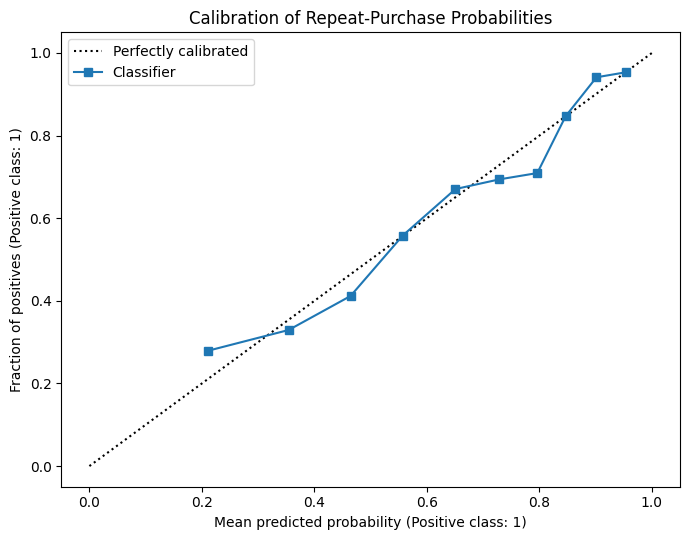

In [16]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

brier_score = brier_score_loss(
    y_test,
    y_probability
)

print(f"Brier score: {brier_score:.4f}")

fig, ax = plt.subplots(figsize=(7, 5.5))

CalibrationDisplay.from_predictions(
    y_test,
    y_probability,
    n_bins=10,
    strategy="quantile",
    ax=ax
)



ax.set_title("Calibration of Repeat-Purchase Probabilities")
ax.legend()

plt.tight_layout()
plt.savefig(
    "logistic_probability_calibration.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Probability Calibration Results

Probability calibration evaluates whether the probabilities predicted by the logistic regression correspond to the observed proportions of repeat purchasers.

For example, among customers assigned a predicted probability of approximately 0.80, a well-calibrated model should observe a repeat-purchase rate close to 80%.

A perfectly calibrated model follows the diagonal line:

$$
\text{Observed repeat rate}
=
\text{Predicted repeat probability}
$$

The calibration curve remained reasonably close to the diagonal across most probability ranges. This indicates that the logistic regression probabilities generally correspond well with the observed repeat-purchase proportions.

Some small deviations were observed. At certain probability levels around 0.70 to 0.80, the model slightly overestimated the probability of repeat purchasing. At several lower and higher probability levels, it slightly underestimated the observed probability. However, these deviations were not severe.

The Brier score was:

$$
\text{Brier Score}=0.1777
$$

The Brier score is calculated as:

$$
\text{Brier Score}
=
\frac{1}{n}
\sum_{i=1}^{n}
(\hat p_i-y_i)^2
$$

where \(\hat p_i\) is the predicted probability and \(y_i\) is the actual repeat-purchase outcome.

A Brier score of zero represents perfect probability predictions. Lower scores indicate better probability accuracy. There is no single universal threshold for an acceptable Brier score because its interpretation depends on the outcome prevalence and the performance of a simple baseline model.

Overall, the calibration curve and Brier score indicate that the predicted probabilities are sufficiently reliable for use in the Customer Lifetime Value calculation. Therefore, additional probability recalibration is not required at this stage.


In [17]:
repeat_rate = y_test.mean()

baseline_probabilities = np.full(
    len(y_test),
    repeat_rate
)

baseline_brier = brier_score_loss(
    y_test,
    baseline_probabilities
)

brier_improvement = (
    (baseline_brier - brier_score)
    / baseline_brier
) * 100

print(f"Model Brier score: {brier_score:.4f}")
print(f"Baseline Brier score: {baseline_brier:.4f}")
print(f"Improvement over baseline: {brier_improvement:.2f}%")

Model Brier score: 0.1777
Baseline Brier score: 0.2306
Improvement over baseline: 22.94%


In [18]:
fold_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": cv_scores["test_Accuracy"],
    "Precision": cv_scores["test_Precision"],
    "Recall": cv_scores["test_Recall"],
    "Specificity": cv_scores["test_Specificity"],
    "F1-score": cv_scores["test_F1"],
    "ROC-AUC": cv_scores["test_ROC_AUC"],
    "PR-AUC": cv_scores["test_PR_AUC"]
})

fold_results.round(4)

,Fold,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,PR-AUC
0,1,0.7321,0.7608,0.8463,0.5304,0.8013,0.7877,0.8639
1,2,0.7262,0.7556,0.8440,0.5182,0.7974,0.7966,0.8771
2,3,0.7170,0.7547,0.8257,0.5244,0.7886,0.7770,0.8634
3,4,0.7419,0.7697,0.8509,0.5488,0.8083,0.7896,0.8596
4,5,0.6877,0.7290,0.8142,0.4634,0.7692,0.7793,0.8766


In [ ]:
summary_rows = pd.DataFrame({
    "Fold": ["Mean", "Standard deviation"],
    "Accuracy": [
        fold_results["Accuracy"].mean(),
        fold_results["Accuracy"].std()
    ],
    "Precision": [
        fold_results["Precision"].mean(),
        fold_results["Precision"].std()
    ],
    "Recall": [
        fold_results["Recall"].mean(),
        fold_results["Recall"].std()
    ],
    "Specificity": [
        fold_results["Specificity"].mean(),
        fold_results["Specificity"].std()
    ],
    "F1-score": [
        fold_results["F1-score"].mean(),
        fold_results["F1-score"].std()
    ],
    "ROC-AUC": [
        fold_results["ROC-AUC"].mean(),
        fold_results["ROC-AUC"].std()
    ],
    "PR-AUC": [
        fold_results["PR-AUC"].mean(),
        fold_results["PR-AUC"].std()
    ]
})

complete_cv_results = pd.concat(
    [fold_results, summary_rows],
    ignore_index=True
)

complete_cv_results.round(4)

,Fold,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,PR-AUC
0,1,0.7321,0.7608,0.8463,0.5304,0.8013,0.7877,0.8639
1,2,0.7262,0.7556,0.8440,0.5182,0.7974,0.7966,0.8771
2,3,0.7170,0.7547,0.8257,0.5244,0.7886,0.7770,0.8634
3,4,0.7419,0.7697,0.8509,0.5488,0.8083,0.7896,0.8596
4,5,0.6877,0.7290,0.8142,0.4634,0.7692,0.7793,0.8766
5,Mean,0.7210,0.7540,0.8362,0.5170,0.7930,0.7860,0.8681
6,Standard deviation,0.0207,0.0152,0.0156,0.0321,0.0150,0.0080,0.0081


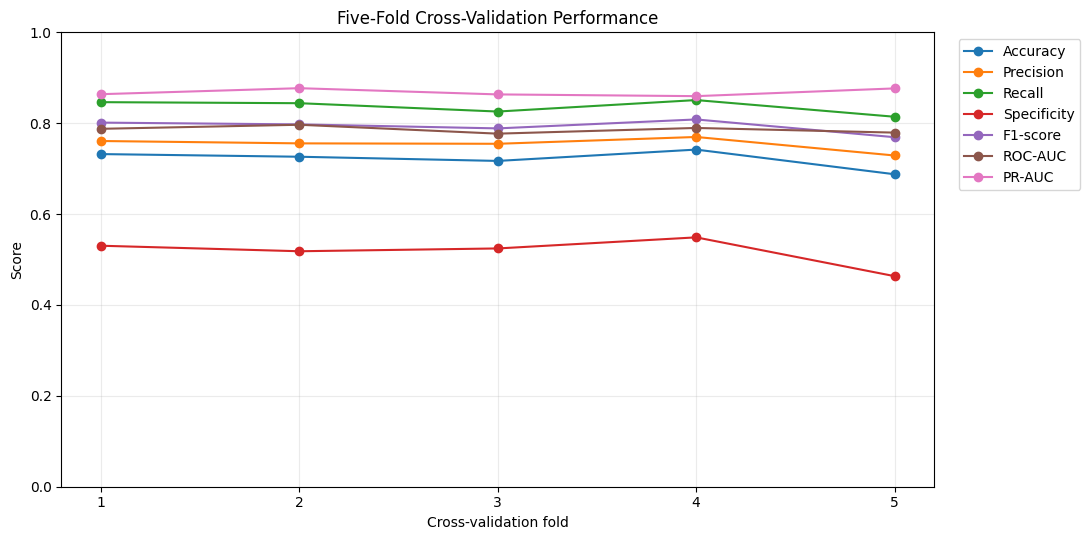

In [19]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1-score",
    "ROC-AUC",
    "PR-AUC"
]

plt.figure(figsize=(11, 5.5))

for metric in metric_columns:
    plt.plot(
        fold_results["Fold"],
        fold_results[metric],
        marker="o",
        label=metric
    )

plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0, 1)
plt.xlabel("Cross-validation fold")
plt.ylabel("Score")
plt.title("Five-Fold Cross-Validation Performance")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(
    "logistic_cross_validation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Five-Fold Cross-Validation Results

Five-fold stratified cross-validation was conducted on the training data to evaluate whether the logistic regression model performed consistently across different subsets of customers.

The model achieved the following average performance:

* Accuracy: \(0.7210\pm0.0207\)
* Precision: \(0.7540\pm0.0152\)
* Recall: \(0.8362\pm0.0156\)
* Specificity: \(0.5170\pm0.0321\)
* F1-score: \(0.7930\pm0.0150\)
* ROC-AUC: \(0.7860\pm0.0080\)
* PR-AUC: \(0.8681\pm0.0081\)

The average cross-validation accuracy was 72.10%, which remained higher than the majority-class baseline of approximately 63.9%. Therefore, the model provided better predictions than simply assigning every customer to the returning-customer class.

The average recall was 83.62%. This means that the model identified approximately 84% of returning customers across the five validation folds. Recall also had a relatively small standard deviation of 0.0156, showing that the model consistently identified returning customers.

The mean specificity was 51.70%. Therefore, the model was less successful at identifying customers who did not return. Specificity also showed the greatest variation across the folds, ranging from 46.34% to 54.88%. This indicates that identifying non-returning customers is the more difficult part of the classification problem.

The mean ROC-AUC was 0.7860 with a standard deviation of only 0.0080. The small standard deviation indicates that the model’s ability to rank returning customers above non-returning customers was highly consistent across all five folds.

Similarly, the mean PR-AUC was 0.8681 with a standard deviation of 0.0081. This shows stable precision-recall performance across the different validation subsets.

The fifth fold produced the lowest accuracy of 68.77%, primarily because its specificity decreased to 46.34%. However, its ROC-AUC and PR-AUC remained close to the overall averages. Therefore, the lower accuracy does not indicate a major failure of the model.

### Comparison with the Test-Set Results

The held-out test set produced an accuracy of 73.65% and a ROC-AUC of 0.7897. These values are close to the cross-validation averages of 72.10% and 0.7860, respectively.

The consistency between the cross-validation and test-set results indicates that the model generalises reasonably well to unseen customers. There is no strong evidence that the logistic regression model is substantially overfitting the training data.

### Final Model Conclusion

The logistic regression model demonstrates stable and acceptable predictive performance. It is particularly effective at identifying customers who will make a future purchase, although it is less effective at identifying customers who will not return.

The predicted repeat-purchase probability can therefore be used as the first component of the Customer Lifetime Value calculation:

$$
\widehat{CLV}_i
=
\widehat{P}(\text{Repeat Purchase}_i=1)
\times
\widehat{E}(\text{Future Revenue}_i\mid\text{Repeat Purchase}_i=1)
$$


### Future-Revenue Regression

A multiple linear regression model is used to predict the future revenue of customers who make a repeat purchase. Only customers with positive future revenue are used to estimate this conditional revenue model.

Because future revenue is strongly right-skewed, the model predicts:

$$
Y_i=\log(1+\text{FutureRevenue}_i)
$$

The regression model is:

$$
Y_i=\beta_0+\beta_1X_{i1}+\cdots+\beta_kX_{ik}+\epsilon_i
$$

The logarithmic transformation reduces the influence of extremely high-revenue customers and makes the relationship more suitable for linear regression.


In [20]:
revenue_data = model_data[
    (model_data["RepeatPurchase"] == 1) &
    (model_data["FutureRevenue"] > 0)
].copy()

print("Customers used for revenue model:", len(revenue_data))

Customers used for revenue model: 2726


In [21]:
X_revenue = revenue_data[features].copy()

y_revenue_log = np.log1p(
    revenue_data["FutureRevenue"]
)

In [23]:
from sklearn.model_selection import train_test_split

(
    X_train_revenue,
    X_test_revenue,
    y_train_revenue,
    y_test_revenue
) = train_test_split(
    X_revenue,
    y_revenue_log,
    test_size=0.20,
    random_state=42
)

print("Training customers:", len(X_train_revenue))
print("Testing customers:", len(X_test_revenue))

Training customers: 2180
Testing customers: 546


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

revenue_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

revenue_model.fit(
    X_train_revenue,
    y_train_revenue
)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [25]:
predicted_log_revenue = revenue_model.predict(
    X_test_revenue
)

train_log_predictions = revenue_model.predict(
    X_train_revenue
)

In [26]:
train_residuals = (
    y_train_revenue - train_log_predictions
)

smearing_factor = np.mean(
    np.exp(train_residuals)
)

predicted_revenue = (
    np.exp(predicted_log_revenue)
    * smearing_factor
) - 1

predicted_revenue = np.maximum(
    predicted_revenue,
    0
)

actual_revenue = np.expm1(
    y_test_revenue
)

print(f"Smearing factor: {smearing_factor:.4f}")

Smearing factor: 1.5600


In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

revenue_metrics = pd.Series({
    "Log-scale R-squared": r2_score(
        y_test_revenue,
        predicted_log_revenue
    ),
    "Revenue-scale R-squared": r2_score(
        actual_revenue,
        predicted_revenue
    ),
    "MAE": mean_absolute_error(
        actual_revenue,
        predicted_revenue
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            actual_revenue,
            predicted_revenue
        )
    )
})

revenue_metrics.round(4)

,0
Log-scale R-squared,0.4895
Revenue-scale R-squared,0.6839
MAE,1023.8521
RMSE,1933.2776


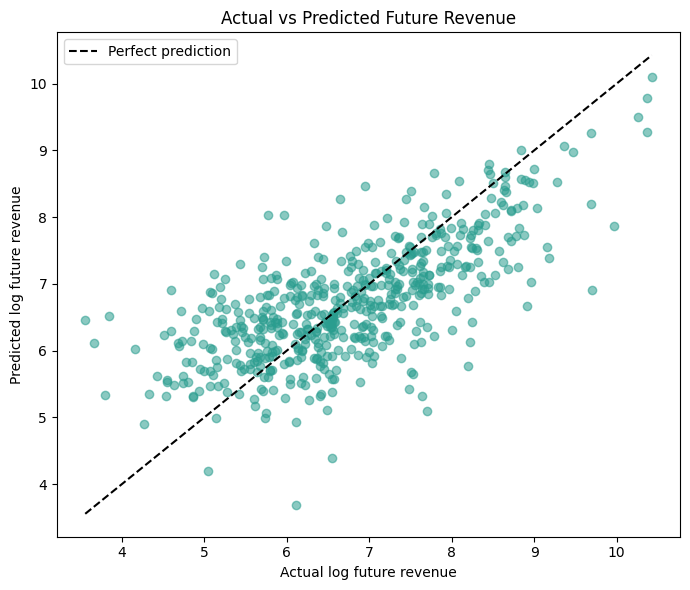

In [28]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test_revenue,
    predicted_log_revenue,
    alpha=0.55,
    color="#2A9D8F"
)

minimum_value = min(
    y_test_revenue.min(),
    predicted_log_revenue.min()
)

maximum_value = max(
    y_test_revenue.max(),
    predicted_log_revenue.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    color="black",
    label="Perfect prediction"
)

plt.xlabel("Actual log future revenue")
plt.ylabel("Predicted log future revenue")
plt.title("Actual vs Predicted Future Revenue")
plt.legend()

plt.tight_layout()
plt.savefig(
    "future_revenue_regression.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [29]:
revenue_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": revenue_model
        .named_steps["model"]
        .coef_
}).sort_values(
    "Coefficient",
    ascending=False
)

revenue_coefficients.round(4)

,Feature,Coefficient
1,LogFrequency,1.9460
3,LogAverageOrderValue,1.4779
4,LogTotalQuantity,0.0849
6,IsUK,-0.0810
5,LogProductDiversity,-0.0978
0,RecencyDays,-0.1004
2,LogMonetaryValue,-1.7252


In [30]:
revenue_features = [
    "RecencyDays",
    "LogFrequency",
    "LogAverageOrderValue",
    "LogTotalQuantity",
    "LogProductDiversity",
    "IsUK"
]

X_revenue = revenue_data[
    revenue_features
].copy()

y_revenue_log = np.log1p(
    revenue_data["FutureRevenue"]
)

In [31]:
(
    X_train_revenue,
    X_test_revenue,
    y_train_revenue,
    y_test_revenue
) = train_test_split(
    X_revenue,
    y_revenue_log,
    test_size=0.20,
    random_state=42
)

In [32]:
revenue_model.fit(
    X_train_revenue,
    y_train_revenue
)

predicted_log_revenue = revenue_model.predict(
    X_test_revenue
)

train_log_predictions = revenue_model.predict(
    X_train_revenue
)

train_residuals = (
    y_train_revenue - train_log_predictions
)

smearing_factor = np.mean(
    np.exp(train_residuals)
)

predicted_revenue = (
    np.exp(predicted_log_revenue)
    * smearing_factor
) - 1

predicted_revenue = np.maximum(
    predicted_revenue,
    0
)

actual_revenue = np.expm1(
    y_test_revenue
)

In [33]:
revenue_metrics = pd.Series({
    "Log-scale R-squared": r2_score(
        y_test_revenue,
        predicted_log_revenue
    ),
    "Revenue-scale R-squared": r2_score(
        actual_revenue,
        predicted_revenue
    ),
    "MAE": mean_absolute_error(
        actual_revenue,
        predicted_revenue
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            actual_revenue,
            predicted_revenue
        )
    )
})

revenue_metrics.round(4)

,0
Log-scale R-squared,0.4724
Revenue-scale R-squared,0.6807
MAE,1048.0656
RMSE,1943.1729


In [34]:
revenue_coefficients = pd.DataFrame({
    "Feature": revenue_features,
    "Coefficient": revenue_model
        .named_steps["model"]
        .coef_
}).sort_values(
    "Coefficient",
    ascending=False
)

revenue_coefficients.round(4)

,Feature,Coefficient
1,LogFrequency,0.7402
2,LogAverageOrderValue,0.5801
3,LogTotalQuantity,0.0030
0,RecencyDays,-0.0747
5,IsUK,-0.0791
4,LogProductDiversity,-0.1254


The corrected revenue model explained 68.07% of the variation in future revenue. Purchase frequency and average order value were the strongest positive predictors, while customers with greater recency generally generated less future revenue. Removing the redundant monetary-value predictor produced more interpretable coefficients with only a small reduction in predictive performance.


In [35]:
# Final repeat-purchase model
logistic_model.fit(X, y)

# Final conditional revenue model
revenue_model.fit(
    X_revenue,
    y_revenue_log
)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [36]:
full_revenue_log_predictions = revenue_model.predict(
    X_revenue
)

full_revenue_residuals = (
    y_revenue_log -
    full_revenue_log_predictions
)

final_smearing_factor = np.mean(
    np.exp(full_revenue_residuals)
)

print(
    f"Final smearing factor: "
    f"{final_smearing_factor:.4f}"
)

Final smearing factor: 1.5407


In [37]:
model_data["RepeatProbability"] = (
    logistic_model.predict_proba(X)[:, 1]
)

all_revenue_inputs = model_data[
    revenue_features
]

predicted_conditional_log_revenue = (
    revenue_model.predict(all_revenue_inputs)
)

model_data["ConditionalFutureRevenue"] = (
    np.exp(predicted_conditional_log_revenue)
    * final_smearing_factor
) - 1

model_data["ConditionalFutureRevenue"] = (
    model_data["ConditionalFutureRevenue"]
    .clip(lower=0)
)

In [38]:
model_data["PredictedCLV"] = (
    model_data["RepeatProbability"]
    *
    model_data["ConditionalFutureRevenue"]
)

CLV
i​=P
(Repeat Purchasei​)×E
(Future Revenuei​∣Repeat Purchasei​=1)

In [39]:
model_data["CLVSegment"] = pd.qcut(
    model_data["PredictedCLV"].rank(
        method="first"
    ),
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [40]:
clv_summary = (
    model_data
    .groupby("CLVSegment", observed=True)
    .agg(
        Customers=("CustomerID", "count"),
        MeanCLV=("PredictedCLV", "mean"),
        MedianCLV=("PredictedCLV", "median"),
        MeanRepeatProbability=(
            "RepeatProbability",
            "mean"
        )
    )
)

clv_summary.round(2)

,Customers,MeanCLV,MedianCLV,MeanRepeatProbability
CLVSegment,,,,
Low,1067,127.42,124.61,0.33
Medium,1066,422.84,413.00,0.58
High,1066,1026.00,1000.18,0.75
Very High,1067,5062.58,2727.71,0.89


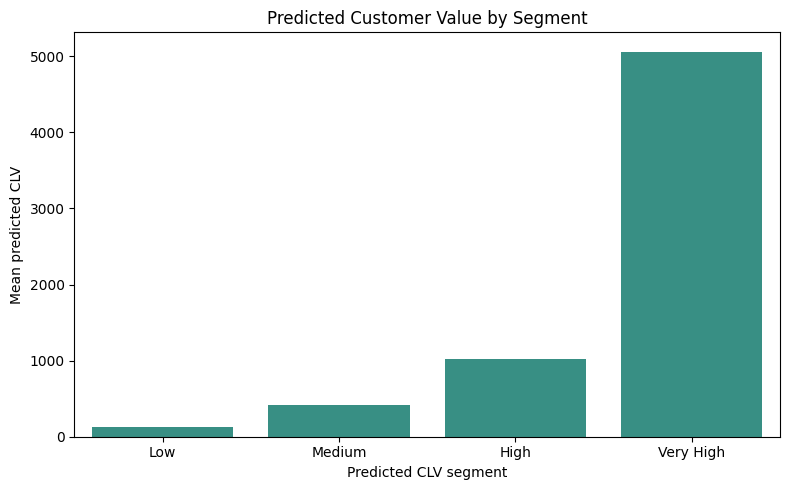

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_data,
    x="CLVSegment",
    y="PredictedCLV",
    order=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    color="#2A9D8F",
    errorbar=None
)

plt.xlabel("Predicted CLV segment")
plt.ylabel("Mean predicted CLV")
plt.title("Predicted Customer Value by Segment")

plt.tight_layout()
plt.savefig(
    "predicted_clv_segments.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [42]:
clv_results = model_data[[
    "CustomerID",
    "RepeatProbability",
    "ConditionalFutureRevenue",
    "PredictedCLV",
    "CLVSegment"
]].sort_values(
    "PredictedCLV",
    ascending=False
)

clv_results.to_csv(
    "/content/drive/MyDrive/Data/data/processed/customer_clv_predictions.csv",
    index=False
)

clv_results.head(10)

,CustomerID,RepeatProbability,ConditionalFutureRevenue,PredictedCLV,CLVSegment
4141,18102,0.997200,185385.965243,184866.810354,Very High
1620,14646,0.997666,174672.782531,174265.183283,Very High
1256,14156,0.998005,137427.208316,137153.065020,Very High
1822,14911,0.998842,113358.884285,113227.656148,Very High
926,13694,0.997356,80606.624950,80393.494191,Very High
1931,15061,0.995559,57618.230787,57362.373121,Very High
4026,17949,0.993820,54327.090881,53991.349822,Very High
3095,16684,0.989133,54150.261810,53561.823202,Very High
3143,16754,0.987086,50502.119018,49849.943004,Very High
3709,17511,0.990598,47540.458177,47093.501651,Very High


# **Experimental Design for Customer Retention**

The proposed experiment evaluates whether a 10% discount or free delivery increases customer revenue compared with no offer. Customers are blocked according to their predicted CLV segment and randomly assigned to one of the three treatments within each segment. Therefore, a Randomised Complete Block Design is recommended. The response variable is customer revenue generated within 60 days after receiving the offer.

In [44]:
import numpy as np
import pandas as pd

treatments = [
    "Control",
    "10% Discount",
    "Free Delivery"
]

segments = [
    "Low",
    "Medium",
    "High",
    "Very High"
]

rng = np.random.default_rng(42)
experiment_groups = []

for segment in segments:

    group = clv_results[
        clv_results["CLVSegment"] == segment
    ].copy()

    shuffled_indices = rng.permutation(
        group.index
    )

    group = group.loc[
        shuffled_indices
    ].copy()

    group["Treatment"] = np.resize(
        treatments,
        len(group)
    )

    experiment_groups.append(group)

experiment_plan = pd.concat(
    experiment_groups,
    ignore_index=True
)

experiment_plan.head()

,CustomerID,RepeatProbability,ConditionalFutureRevenue,PredictedCLV,CLVSegment,Treatment
0,14858,0.367283,396.751325,145.719955,Low,Control
1,15848,0.241749,250.566913,60.574208,Low,10% Discount
2,14674,0.365023,372.286152,135.893180,Low,Free Delivery
3,14678,0.349254,677.247434,236.531105,Low,Control
4,14086,0.216872,135.427675,29.370446,Low,10% Discount


In [45]:
allocation_table = pd.crosstab(
    experiment_plan["CLVSegment"],
    experiment_plan["Treatment"]
)

allocation_table

Treatment,10% Discount,Control,Free Delivery
CLVSegment,,,
Low,356,356,355
Medium,355,356,355
High,355,356,355
Very High,356,356,355


In [ ]:
experiment_plan.to_csv(
    "/content/drive/MyDrive/Data/data/processed/customer_experiment_plan.csv",
    index=False
)

The treatment hypotheses are:

$$H_0: \mu_{\text{Control}} = \mu_{\text{Discount}} = \mu_{\text{Free Delivery}}$$

$$H_1: \text{At least one treatment mean is different}$$

After collecting 60-day revenue, a two-way ANOVA can test the treatment effect while controlling for CLV segment. No ANOVA is currently performed because the historical dataset does not contain observations from this proposed experiment.

In [48]:
important_words = [
    "model",
    "scaler",
    "scale",
    "pipeline",
    "feature"
]

for name in sorted(globals()):
    if any(
        word in name.lower()
        for word in important_words
    ):
        try:
            print(
                f"{name:35s}",
                type(globals()[name]).__name__
            )
        except Exception:
            pass

Pipeline                            ABCMeta
StandardScaler                      type
features                            list
logistic_model                      Pipeline
model_data                          DataFrame
revenue_features                    list
revenue_model                       Pipeline


In [49]:
print("Logistic model type:")
print(type(logistic_model))

print("\nLogistic model:")
print(logistic_model)

Logistic model type:
<class 'sklearn.pipeline.Pipeline'>

Logistic model:
Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])


In [50]:
classification_features = [
    "RecencyDays",
    "LogFrequency",
    "LogMonetaryValue",
    "LogAverageOrderValue",
    "LogTotalQuantity",
    "LogProductDiversity",
    "IsUK"
]

X_all_classification = customer_data[
    classification_features
]

repeat_probability = logistic_model.predict_proba(
    X_all_classification
)[:, 1]

In [51]:
print(
    "Expected number of features:",
    logistic_model.n_features_in_
)

if hasattr(logistic_model, "feature_names_in_"):
    print(
        "Expected features:",
        logistic_model.feature_names_in_
    )
else:
    print(
        "Feature names were not stored because the "
        "model was probably trained using a NumPy array."
    )

Expected number of features: 7
Expected features: ['RecencyDays' 'LogFrequency' 'LogMonetaryValue' 'LogAverageOrderValue'
 'LogTotalQuantity' 'LogProductDiversity' 'IsUK']


In [52]:
print(
    "Provided number of features:",
    len(classification_features)
)

Provided number of features: 7


In [53]:
prediction_path = (
    "/content/drive/MyDrive/Data/data/processed/"
    "customer_clv_predictions.csv"
)

predictions = pd.read_csv(
    prediction_path
)

print(predictions.shape)
print(predictions.columns.tolist())

predictions.head()

(4266, 5)
['CustomerID', 'RepeatProbability', 'ConditionalFutureRevenue', 'PredictedCLV', 'CLVSegment']


,CustomerID,RepeatProbability,ConditionalFutureRevenue,PredictedCLV,CLVSegment
0,18102,0.997200,185385.965243,184866.810354,Very High
1,14646,0.997666,174672.782531,174265.183283,Very High
2,14156,0.998005,137427.208316,137153.065020,Very High
3,14911,0.998842,113358.884285,113227.656148,Very High
4,13694,0.997356,80606.624950,80393.494191,Very High


In [54]:
for name in sorted(globals()):
    if any(
        word in name.lower()
        for word in [
            "model",
            "scaler",
            "scale",
            "pipeline",
            "feature"
        ]
    ):
        print(
            name,
            type(globals()[name]).__name__
        )

Pipeline ABCMeta
StandardScaler type
classification_features list
features list
logistic_model Pipeline
model_data DataFrame
revenue_features list
revenue_model Pipeline
